In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# CELL 2: LOAD DATASET
# ============================================================

df = pd.read_csv("health_lifestyle_dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (100000, 16)


,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


In [4]:
# ============================================================
# CELL 3: INITIAL INSPECTION
# ============================================================

print("Column names:")
print(df.columns.tolist())

print("\nDataset info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values per column:")
print(df.nunique())

Column names:
['id', 'age', 'gender', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l', 'calories_consumed', 'smoker', 'alcohol', 'resting_hr', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'family_history', 'disease_risk']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 100000 non-null  int64  
 1   age                100000 non-null  int64  
 2   gender             100000 non-null  object 
 3   bmi                100000 non-null  float64
 4   daily_steps        100000 non-null  int64  
 5   sleep_hours        100000 non-null  float64
 6   water_intake_l     100000 non-null  float64
 7   calories_consumed  100000 non-null  int64  
 8   smoker             100000 non-null  int64  
 9   alcohol            100000 non-null  int64  
 10  resting_hr         100000 non-null  int64  
 11  syst

In [5]:
# ============================================================
# CELL 4: BASIC PREPROCESSING
# ============================================================

# Clean gender values
df["gender"] = df["gender"].astype(str).str.strip().str.lower()
df["gender"] = df["gender"].replace({"m": "male", "f": "female"})

# Convert binary-like columns to integer
binary_cols = ["smoker", "alcohol", "family_history", "disease_risk"]
for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

print("Gender distribution after cleaning:")
print(df["gender"].value_counts())

print("\nPreview after preprocessing:")
display(df.head())

Gender distribution after cleaning:
gender
male      50132
female    49868
Name: count, dtype: int64

Preview after preprocessing:


,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


In [6]:
# ============================================================
# CELL 5: CREATE NEW TARGET VARIABLE
# HIGH_BP = 1 if systolic_bp > 190 or diastolic_bp > 90
# otherwise 0
# ============================================================

df["HIGH_BP"] = np.where(
    (df["systolic_bp"] > 190) | (df["diastolic_bp"] > 90),
    1,
    0
)

print("HIGH_BP target created successfully.")
print(df["HIGH_BP"].value_counts())

HIGH_BP target created successfully.
HIGH_BP
0    51751
1    48249
Name: count, dtype: int64


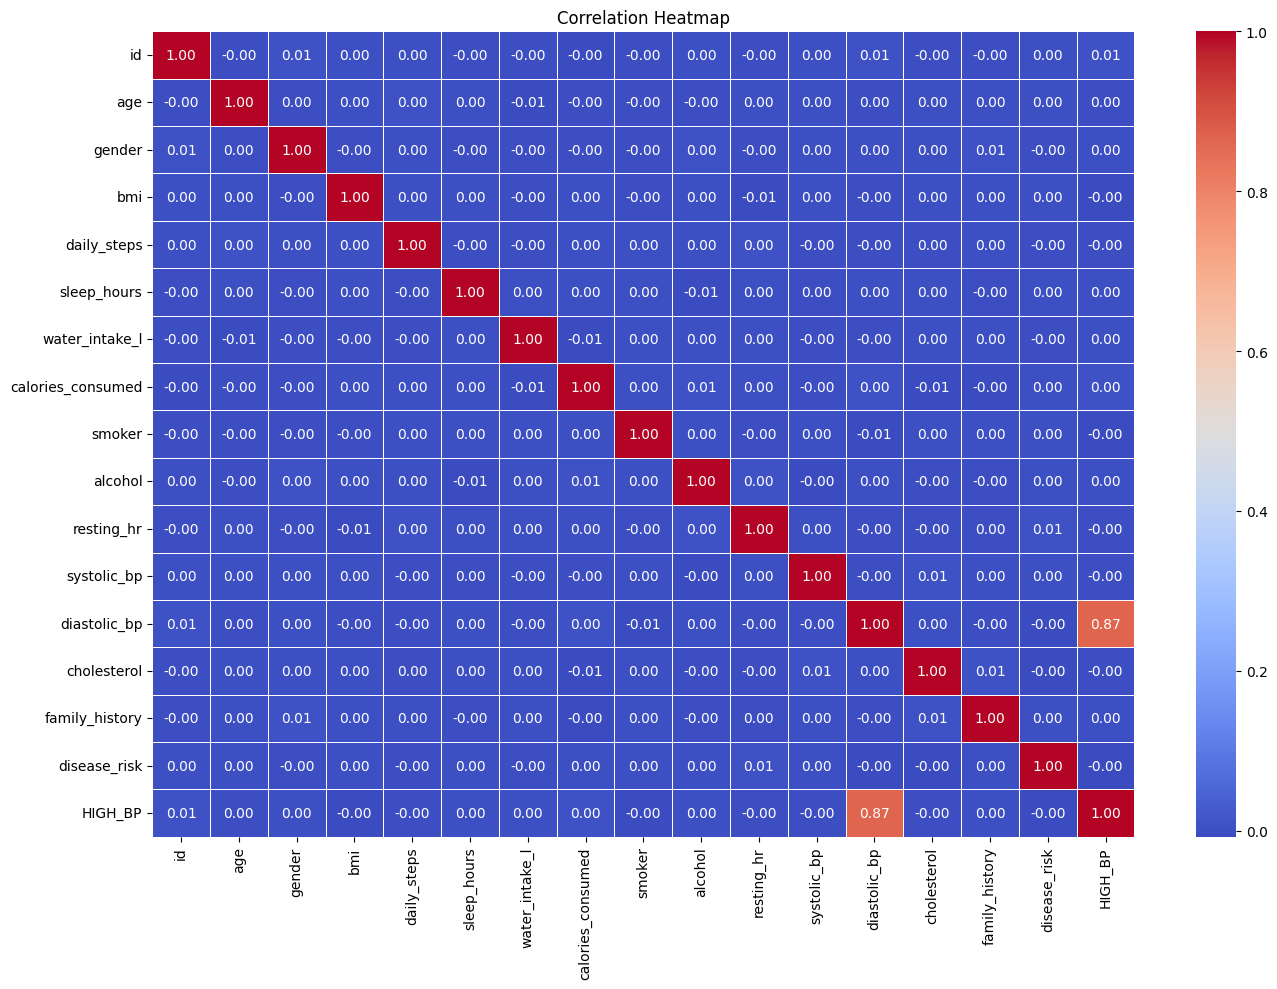

In [8]:
# ============================================================
# CELL 6: CORRELATION HEATMAP
# ============================================================

heatmap_df = df.copy()
heatmap_df["gender"] = heatmap_df["gender"].map({"male": 1, "female": 0})

plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

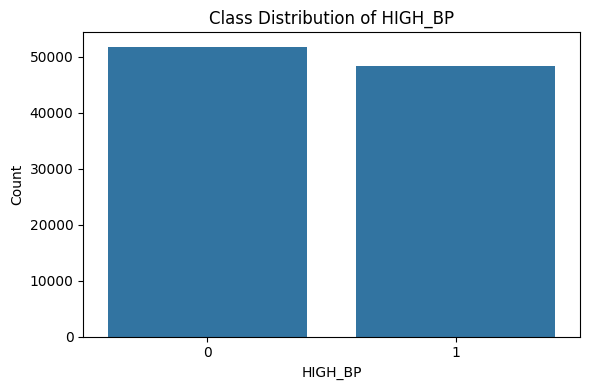

HIGH_BP
0    51751
1    48249
Name: count, dtype: int64


In [9]:
# ============================================================
# CELL 7: TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))
sns.countplot(x="HIGH_BP", data=df)
plt.title("Class Distribution of HIGH_BP")
plt.xlabel("HIGH_BP")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df["HIGH_BP"].value_counts())

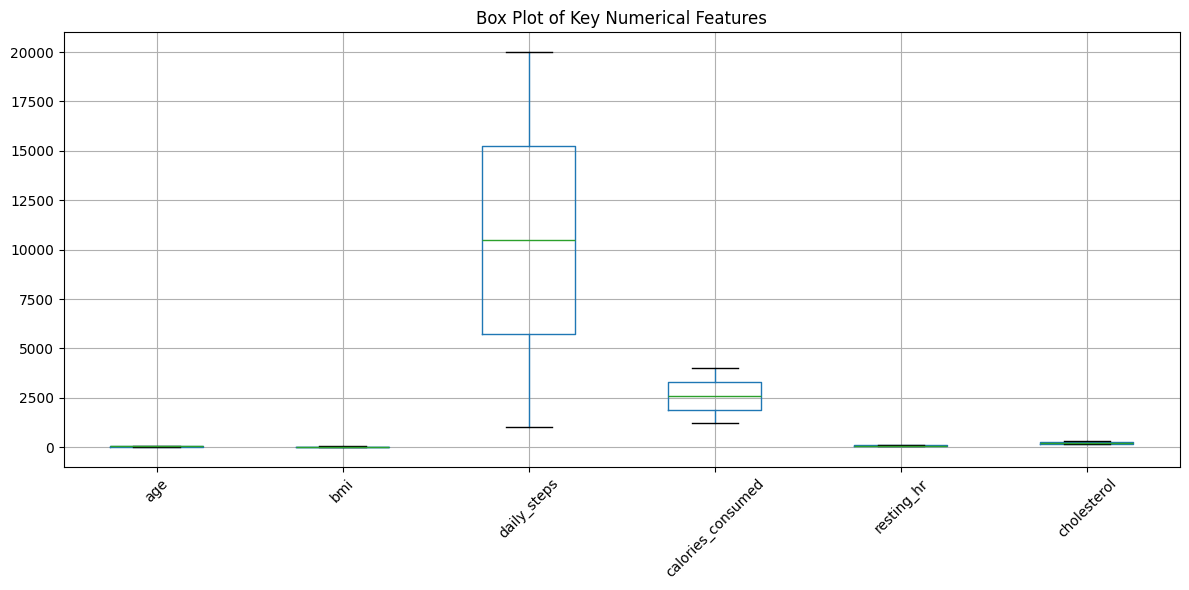

In [10]:
# ============================================================
# CELL 8: BOXPLOT OF IMPORTANT NUMERICAL FEATURES
# ============================================================

num_cols = ["age", "bmi", "daily_steps", "calories_consumed", "resting_hr", "cholesterol"]

plt.figure(figsize=(12, 6))
df[num_cols].boxplot(rot=45)
plt.title("Box Plot of Key Numerical Features")
plt.tight_layout()
plt.show()

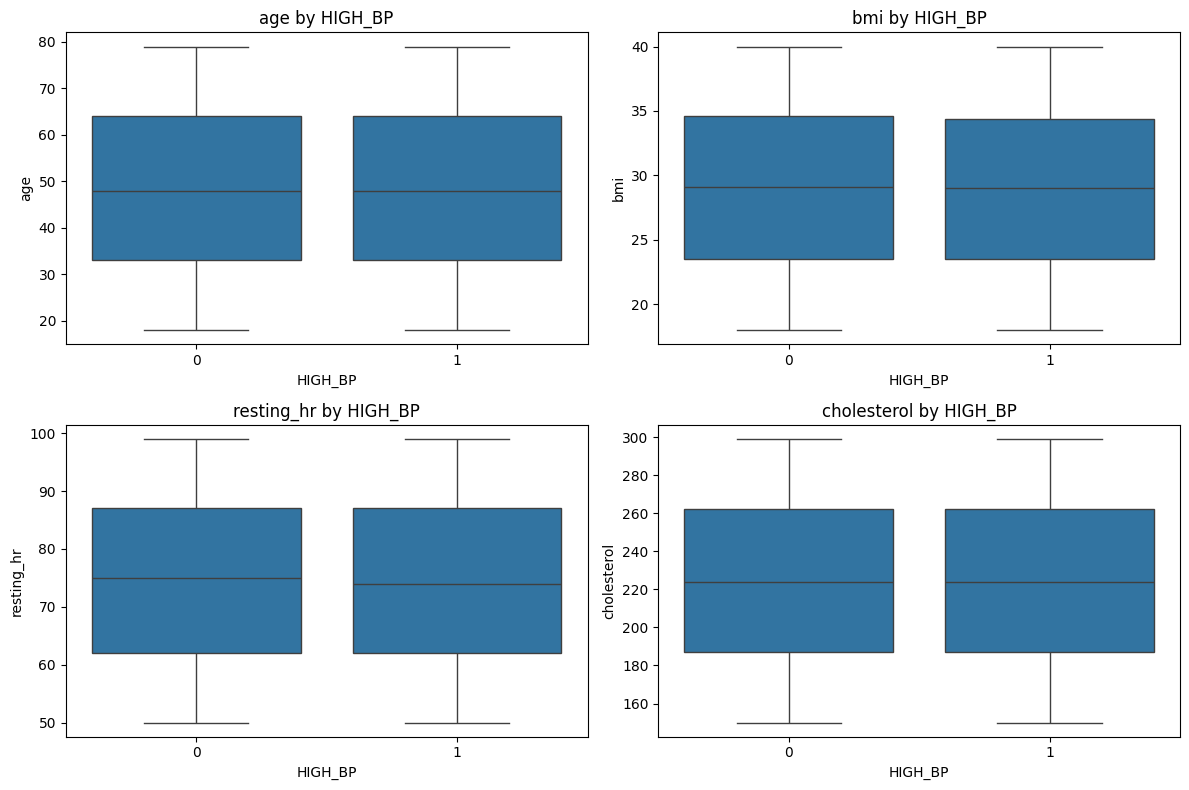

In [11]:
# ============================================================
# CELL 9: FEATURE DISTRIBUTION BY TARGET
# ============================================================

plot_cols = ["age", "bmi", "resting_hr", "cholesterol"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(plot_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x="HIGH_BP", y=col, data=df)
    plt.title(f"{col} by HIGH_BP")

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL 10: DROP COLUMNS
# Drop:
# id, systolic_bp, diastolic_bp, sleep_hours, water_intake_l,
# and old target disease_risk
# ============================================================

df_model = df.drop(
    columns=["id", "systolic_bp", "diastolic_bp",  "disease_risk"],
    errors="ignore"
)

print("Columns after dropping:")
print(df_model.columns.tolist())
display(df_model.head())

Columns after dropping:
['age', 'gender', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l', 'calories_consumed', 'smoker', 'alcohol', 'resting_hr', 'cholesterol', 'family_history', 'HIGH_BP']


,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,cholesterol,family_history,HIGH_BP
0,56,male,20.5,4198,3.9,3.4,1602,0,0,97,240,0,1
1,69,female,33.3,14359,9.0,4.7,2346,0,1,68,207,0,0
2,46,male,31.6,1817,6.6,4.2,1643,0,1,90,296,0,1
3,32,female,38.2,15772,3.6,2.0,2460,0,0,71,175,0,1
4,60,female,33.6,6037,3.8,4.0,3756,0,1,98,294,0,0


In [25]:
# ============================================================
# CELL 11: ONE-HOT ENCODING
# ============================================================

df_model = pd.get_dummies(df_model, drop_first=True)

# Convert boolean columns to integer if created
bool_cols = df_model.select_dtypes(include="bool").columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print("Encoded dataset shape:", df_model.shape)
display(df_model.head())

Encoded dataset shape: (100000, 13)


,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,cholesterol,family_history,HIGH_BP,gender_male
0,56,20.5,4198,3.9,3.4,1602,0,0,97,240,0,1,1
1,69,33.3,14359,9.0,4.7,2346,0,1,68,207,0,0,0
2,46,31.6,1817,6.6,4.2,1643,0,1,90,296,0,1,1
3,32,38.2,15772,3.6,2.0,2460,0,0,71,175,0,1,0
4,60,33.6,6037,3.8,4.0,3756,0,1,98,294,0,0,0


In [26]:
# ============================================================
# CELL 12: DEFINE FEATURES AND TARGET
# ============================================================

X = df_model.drop("HIGH_BP", axis=1)
y = df_model["HIGH_BP"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (100000, 12)
y shape: (100000,)

Target distribution:
HIGH_BP
0    51751
1    48249
Name: count, dtype: int64


In [27]:
# ============================================================
# CELL 13: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (80000, 12)
Testing set shape : (20000, 12)

Training target distribution:
HIGH_BP
0    41401
1    38599
Name: count, dtype: int64

Testing target distribution:
HIGH_BP
0    10350
1     9650
Name: count, dtype: int64


In [28]:
# ============================================================
# CELL 14: FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [29]:
# ============================================================
# CELL 15: APPLY SMOTE TO TRAINING DATA
# ============================================================

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
HIGH_BP
0    41401
1    38599
Name: count, dtype: int64

After SMOTE:
HIGH_BP
1    41401
0    41401
Name: count, dtype: int64


In [30]:
# ============================================================
# CELL 16: EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X_test_data, y_test_data, model_name):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    acc = accuracy_score(y_test_data, y_pred)
    auc = roc_auc_score(y_test_data, y_prob)
    cm = confusion_matrix(y_test_data, y_pred)

    print(f"{model_name} Accuracy: {acc:.4f}")
    print(f"{model_name} ROC-AUC : {auc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test_data, y_pred))
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_test_data, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{model_name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return acc, auc

Random Forest Before SMOTE Accuracy: 0.5043
Random Forest Before SMOTE ROC-AUC : 0.4958

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.63      0.57     10350
           1       0.48      0.37      0.42      9650

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.49     20000
weighted avg       0.50      0.50      0.50     20000

Confusion Matrix:
[[6554 3796]
 [6117 3533]]


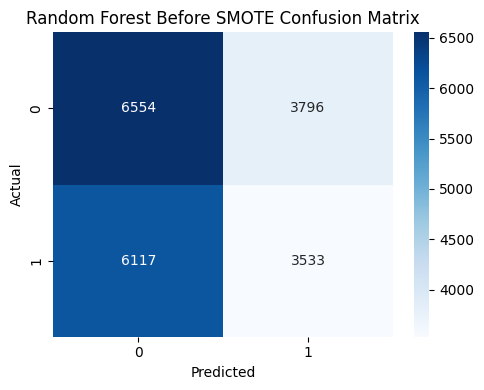

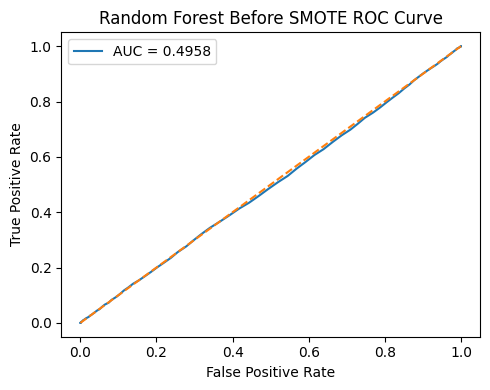

In [31]:
# ============================================================
# CELL 17: RANDOM FOREST BEFORE SMOTE
# ============================================================

rf_before = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_before.fit(X_train_scaled, y_train)

rf_before_acc, rf_before_auc = evaluate_model(
    rf_before, X_test_scaled, y_test, "Random Forest Before SMOTE"
)

Random Forest After SMOTE Accuracy: 0.4947
Random Forest After SMOTE ROC-AUC : 0.4907

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.55      0.53     10350
           1       0.47      0.43      0.45      9650

    accuracy                           0.49     20000
   macro avg       0.49      0.49      0.49     20000
weighted avg       0.49      0.49      0.49     20000

Confusion Matrix:
[[5726 4624]
 [5482 4168]]


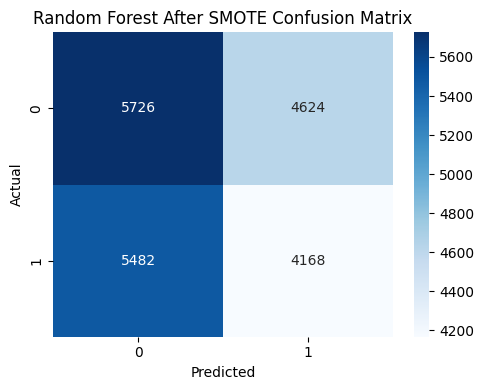

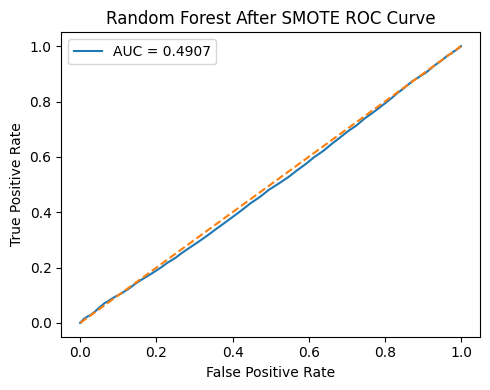

In [32]:
# ============================================================
# CELL 18: RANDOM FOREST AFTER SMOTE
# ============================================================

rf_after = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_after.fit(X_train_smote, y_train_smote)

rf_after_acc, rf_after_auc = evaluate_model(
    rf_after, X_test_scaled, y_test, "Random Forest After SMOTE"
)

In [33]:
# ============================================================
# CELL 19: COMPARE RANDOM FOREST BEFORE AND AFTER SMOTE
# ============================================================

smote_comparison = pd.DataFrame({
    "Model": ["RF Before SMOTE", "RF After SMOTE"],
    "Accuracy": [rf_before_acc, rf_after_acc],
    "ROC-AUC": [rf_before_auc, rf_after_auc]
})

display(smote_comparison)

,Model,Accuracy,ROC-AUC
0,RF Before SMOTE,0.50435,0.495778
1,RF After SMOTE,0.49470,0.490689


Baseline XGBoost Accuracy: 0.5024
Baseline XGBoost ROC-AUC : 0.4962

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.55      0.54     10350
           1       0.48      0.45      0.46      9650

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000

Confusion Matrix:
[[5731 4619]
 [5333 4317]]


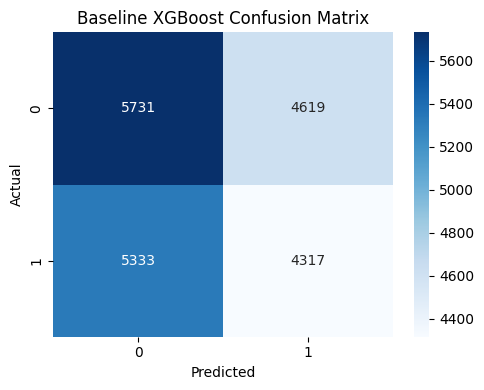

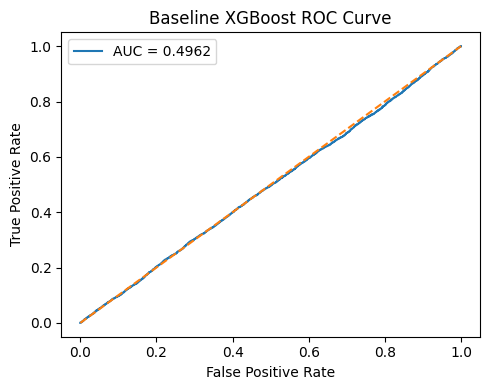

In [34]:
# ============================================================
# CELL 20: BASELINE XGBOOST
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_acc, xgb_auc = evaluate_model(
    xgb_model, X_test_scaled, y_test, "Baseline XGBoost"
)

In [35]:
# ============================================================
# CELL 21: HYPERPARAMETER TUNING FOR XGBOOST
# ============================================================

xgb_param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 9],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_lambda": [1, 5, 10],
    "min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", xgb_search.best_params_)
print("Best CV ROC-AUC:", xgb_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.8, 'reg_lambda': 10, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV ROC-AUC: 0.5157281775117648


Tuned XGBoost Accuracy: 0.4919
Tuned XGBoost ROC-AUC : 0.4901

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.52      0.52     10350
           1       0.47      0.46      0.47      9650

    accuracy                           0.49     20000
   macro avg       0.49      0.49      0.49     20000
weighted avg       0.49      0.49      0.49     20000

Confusion Matrix:
[[5396 4954]
 [5209 4441]]


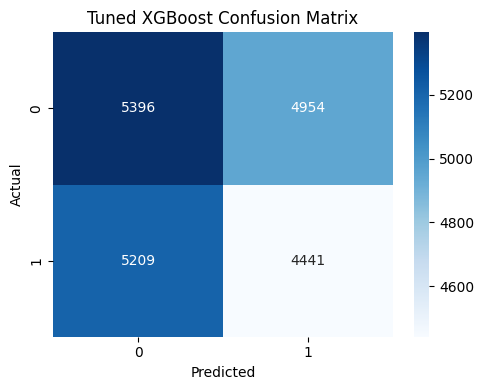

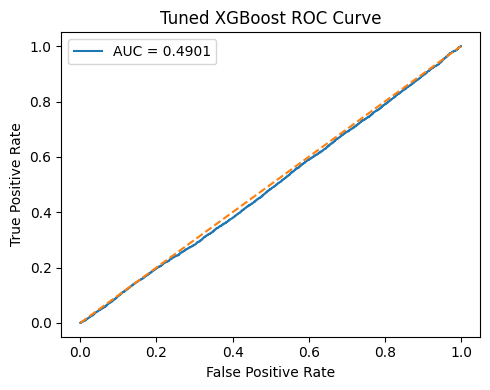

In [36]:
# ============================================================
# CELL 22: EVALUATE TUNED XGBOOST
# ============================================================

xgb_best = xgb_search.best_estimator_

xgb_best_acc, xgb_best_auc = evaluate_model(
    xgb_best, X_test_scaled, y_test, "Tuned XGBoost"
)

Baseline ANN Accuracy: 0.4910
Baseline ANN ROC-AUC : 0.4937

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.42      0.46     10350
           1       0.48      0.57      0.52      9650

    accuracy                           0.49     20000
   macro avg       0.49      0.49      0.49     20000
weighted avg       0.49      0.49      0.49     20000

Confusion Matrix:
[[4319 6031]
 [4149 5501]]


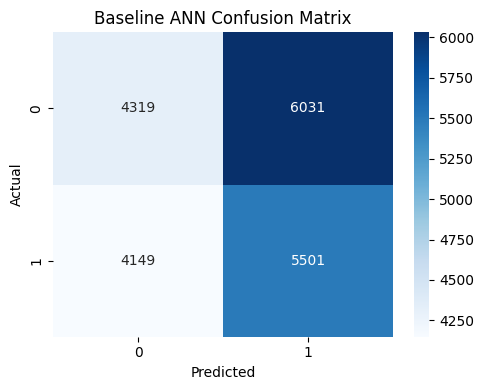

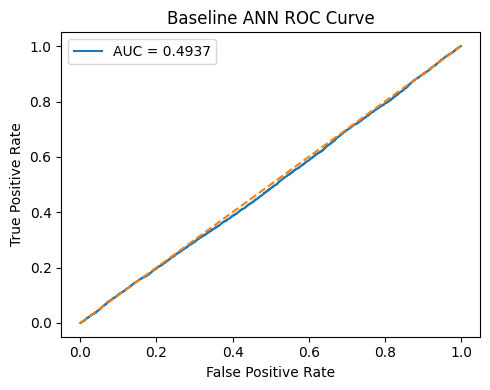

In [37]:
# ============================================================
# CELL 23: BASELINE ANN
# ============================================================

ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=50,
    batch_size=256,
    random_state=42
)

ann_model.fit(X_train_smote, y_train_smote)

ann_acc, ann_auc = evaluate_model(
    ann_model, X_test_scaled, y_test, "Baseline ANN"
)

In [38]:
# ============================================================
# CELL 24: HYPERPARAMETER TUNING FOR ANN
# ============================================================

ann_param_grid = {
    "hidden_layer_sizes": [(64,), (128,), (128, 64), (64, 32)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "batch_size": [128, 256],
    "max_iter": [50, 100]
}

ann_search = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_distributions=ann_param_grid,
    n_iter=8,
    cv=3,
    scoring="roc_auc",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

ann_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", ann_search.best_params_)
print("Best CV ROC-AUC:", ann_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_iter': 100, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (64, 32), 'batch_size': 128, 'alpha': 0.001, 'activation': 'relu'}
Best CV ROC-AUC: 0.5086701961481696


Tuned ANN Accuracy: 0.5020
Tuned ANN ROC-AUC : 0.4977

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.55      0.54     10350
           1       0.48      0.45      0.46      9650

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000

Confusion Matrix:
[[5744 4606]
 [5353 4297]]


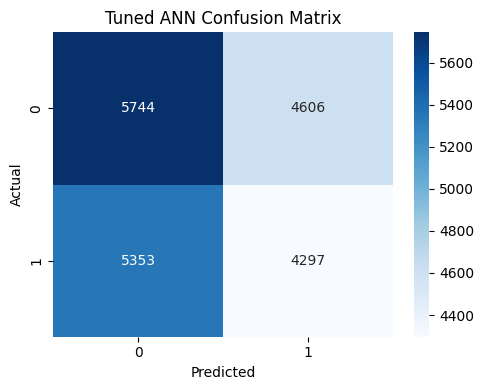

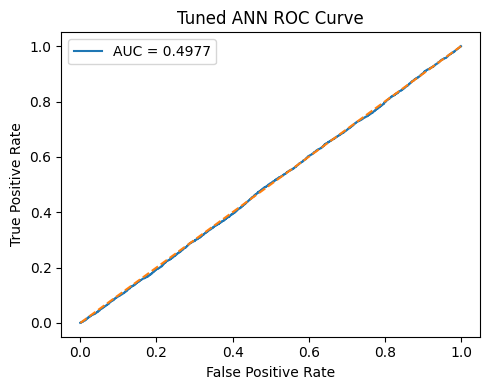

In [39]:
# ============================================================
# CELL 25: EVALUATE TUNED ANN
# ============================================================

ann_best = ann_search.best_estimator_

ann_best_acc, ann_best_auc = evaluate_model(
    ann_best, X_test_scaled, y_test, "Tuned ANN"
)